### Setup and Helpers

In [1]:
import s3fs
import xarray as xr
import numpy as np
import pandas as pd
import pyproj
import matplotlib.pyplot as plt
from pathlib import Path

fs = s3fs.S3FileSystem(anon=True)   # public bucket, no AWS account needed

LOCATIONS = {
    "kingston": (17.9714, -76.7945),
    "montego_bay": (18.47298, -77.92134),
}

def goes_bucket_for(ts_utc):
    """GOES-16 was GOES-East until early April 2025; GOES-19 took over after."""
    return "noaa-goes19" if ts_utc >= pd.Timestamp("2025-04-07", tz="UTC") else "noaa-goes16"

def fetch_band13(ts_local_str):
    """
    Fetch the first Band-13 full-disk scan of the UTC hour matching a
    local-Jamaica timestamp (UTC-5, no DST).
    """

    ts_local = pd.Timestamp(ts_local_str)
    ts_utc = (ts_local + pd.Timedelta(hours=5)).tz_localize("UTC")
    bucket = goes_bucket_for(ts_utc)
    prefix = f"{bucket}/ABI-L2-CMIPF/{ts_utc.year}/{ts_utc.dayofyear:03d}/{ts_utc.hour:02d}/"
    files = [f for f in fs.ls(prefix) if "C13" in f]
    print(f"{ts_local_str} local -> {ts_utc} UTC -> {files[0].split('/')[-1]}")
    return xr.open_dataset(fs.open(files[0]), engine="h5netcdf")

def crop_patch(ds, lat, lon, size=64):
    """
    Crop a size x size pixel patch (2 km/px -> 128x128 km for 64) around
    a lat/lon, using the file's own geostationary projection metadata.
    """
    
    gp = ds["goes_imager_projection"].attrs
    h = gp["perspective_point_height"]
    proj = pyproj.Proj(proj="geos", h=h,
                       lon_0=gp["longitude_of_projection_origin"],
                       sweep=gp["sweep_angle_axis"])
    x_m, y_m = proj(lon, lat)
    xi = int(np.abs(ds.x.values - x_m / h).argmin())
    yi = int(np.abs(ds.y.values - y_m / h).argmin())
    half = size // 2
    return ds["CMI"].isel(y=slice(yi - half, yi + half),
                          x=slice(xi - half, xi + half)).values

### Choosing 3 hours from our Open-Meteo data

In [2]:
def find_project_root(marker="requirements.txt"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError("project root not found")

PROJECT_ROOT = find_project_root()
proc = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "patio_features.parquet")
k = proc[proc["location"] == "kingston"]

# A clear dry afternoon, an ordinary wet-veranda afternoon, and Melissa
dry = k[(k.wet_veranda == 0) & (k.cloud_cover < 10) & (k.hour == 14) & (k.time.dt.year == 2024)].iloc[0]
wet = k[(k.wet_veranda == 1) & (k.precipitation > 1.5) & (k.hour == 14) & (k.time.dt.year == 2024)].iloc[0]
melissa = k[k.time == "2025-10-28 14:00"].iloc[0]

cases = [("Clear / dry", dry), ("Wet-veranda (ordinary)", wet), ("Hurricane Melissa", melissa)]
for name, row in cases:
    print(f"{name}: {row.time}  precip={row.precipitation}mm  gusts={row.wind_gusts_10m}km/h  wet_veranda={row.wet_veranda}")

Clear / dry: 2024-01-12 14:00:00  precip=0.0mm  gusts=45.4km/h  wet_veranda=0
Wet-veranda (ordinary): 2024-02-24 14:00:00  precip=1.8mm  gusts=28.1km/h  wet_veranda=1
Hurricane Melissa: 2025-10-28 14:00:00  precip=5.7mm  gusts=104.4km/h  wet_veranda=1


### Fetch, crop and compare

2024-01-12 14:00:00 local -> 2024-01-12 19:00:00+00:00 UTC -> OR_ABI-L2-CMIPF-M6C13_G16_s20240121900204_e20240121909524_c20240121909581.nc
2024-02-24 14:00:00 local -> 2024-02-24 19:00:00+00:00 UTC -> OR_ABI-L2-CMIPF-M6C13_G16_s20240551900205_e20240551909524_c20240551910000.nc
2025-10-28 14:00:00 local -> 2025-10-28 19:00:00+00:00 UTC -> OR_ABI-L2-CMIPF-M6C13_G19_s20253011900203_e20253011909523_c20253011909586.nc


Text(0.5, 1.02, 'GOES Band-13 (clean IR), 128x128 km patches over Kingston')

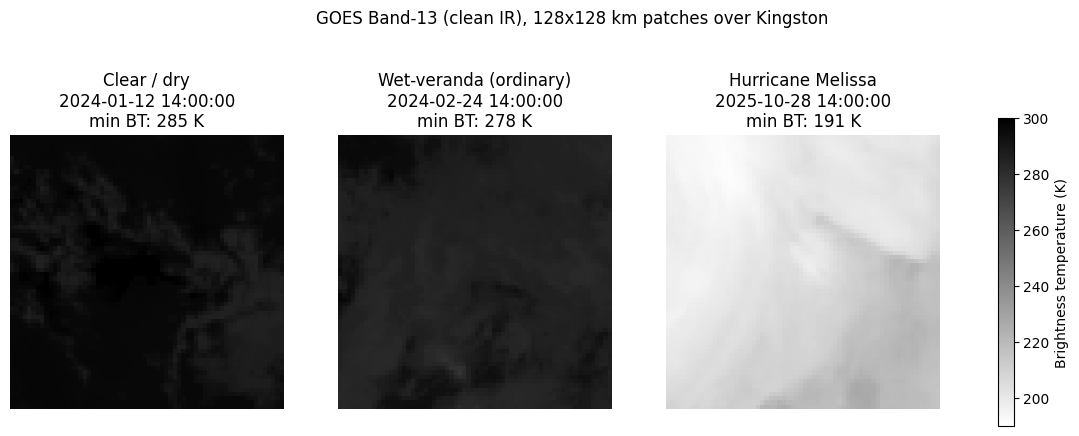

In [3]:
lat, lon = LOCATIONS["kingston"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, row) in zip(axes, cases):
    ds = fetch_band13(str(row.time))
    patch = crop_patch(ds, lat, lon, size=64)
    im = ax.imshow(patch, cmap="gray_r", vmin=190, vmax=300)
    ax.set_title(f"{name}\n{row.time}\nmin BT: {np.nanmin(patch):.0f} K")
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.8, label="Brightness temperature (K)")
plt.suptitle("GOES Band-13 (clean IR), 128x128 km patches over Kingston", y=1.02)

In [5]:
import s3fs, xarray as xr, numpy as np, pandas as pd, pyproj, io, tempfile, os
from pathlib import Path

fs = s3fs.S3FileSystem(anon=True)
LOCATIONS = {"kingston": (17.9714, -76.7945), "montego_bay": (18.47298, -77.92134)}
BANDS = ["C13", "C09", "C02"]

def _proj(ds):
    gp = ds["goes_imager_projection"].attrs
    h = gp["perspective_point_height"]
    return pyproj.Proj(proj="geos", h=h, lon_0=gp["longitude_of_projection_origin"],
                       sweep=gp["sweep_angle_axis"]), h

def crop(ds, lat, lon, size=64):
    p, h = _proj(ds); x_m, y_m = p(lon, lat)
    xi = int(np.abs(ds.x.values - x_m/h).argmin())
    yi = int(np.abs(ds.y.values - y_m/h).argmin())
    half = size//2
    patch = ds["CMI"].isel(y=slice(yi-half, yi+half), x=slice(xi-half, xi+half)).values
    # Band 02 comes in larger (0.5km); downsample to 64x64 to match the IR grid
    if patch.shape[0] != size:
        f = patch.shape[0] // size
        patch = patch[:f*size, :f*size].reshape(size, f, size, f).mean(axis=(1,3))
    return patch.astype("float32")

def band_file(ts_utc, band):
    bucket = "noaa-goes19" if ts_utc >= pd.Timestamp("2025-04-07", tz="UTC") else "noaa-goes16"
    prefix = f"{bucket}/ABI-L2-CMIPF/{ts_utc.year}/{ts_utc.dayofyear:03d}/{ts_utc.hour:02d}/"
    return [f for f in fs.ls(prefix) if band in f][0]

# Sample 5 spread-out hours, build the stacked patch for both cities, measure size
sample_hours = ["2024-07-15 14:00", "2024-11-02 03:00", "2025-01-20 08:00",
                "2025-06-10 17:00", "2025-10-28 14:00"]
sizes = []
for h_local in sample_hours:
    ts_utc = (pd.Timestamp(h_local) + pd.Timedelta(hours=5)).tz_localize("UTC")
    stacks = {}
    for loc, (lat, lon) in LOCATIONS.items():
        chans = []
        for band in BANDS:
            with fs.open(band_file(ts_utc, band)) as f:
                ds = xr.open_dataset(io.BytesIO(f.read()), engine="h5netcdf")
            chans.append(crop(ds, lat, lon))
        stacks[f"{loc}"] = np.stack(chans)   # shape (3, 64, 64)
    
    # measure compressed size of one hour (both locations)
    tmp_path = Path("size_test.npz")
    np.savez_compressed(tmp_path, **stacks)
    sz = tmp_path.stat().st_size
    tmp_path.unlink()
    sizes.append(sz)
    print(f"{h_local}: {sz/1024:.1f} KB per hour (both cities, 3 bands)")

avg = np.mean(sizes)
hours_5yr = 1827 * 24          # full 5-year window, hours
print(f"\nAvg per hour: {avg/1024:.1f} KB")
print(f"Estimated 5-year total: {avg * hours_5yr / 1e9:.2f} GB")
print(f"Estimated 2-year total: {avg * 730 * 24 / 1e9:.2f} GB")

2024-07-15 14:00: 34.1 KB per hour (both cities, 3 bands)
2024-11-02 03:00: 29.5 KB per hour (both cities, 3 bands)
2025-01-20 08:00: 31.5 KB per hour (both cities, 3 bands)
2025-06-10 17:00: 40.5 KB per hour (both cities, 3 bands)
2025-10-28 14:00: 30.5 KB per hour (both cities, 3 bands)

Avg per hour: 33.2 KB
Estimated 5-year total: 1.49 GB
Estimated 2-year total: 0.60 GB


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def find_project_root(marker="requirements.txt"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError("project root not found")

GOES_DIR = find_project_root() / "data" / "raw" / "goes"

# Grab the most recent day-file
f = sorted(GOES_DIR.glob("goes_*.npz"))[-1]
print(f"Inspecting: {f.name}\n")

data = np.load(f)
keys = list(data.keys())
print(f"Total entries: {len(keys)}  (expect 24 hours x 2 cities = 48)")
print("First 4 keys:", keys[:4], "\n")

# Shape + dtype check on one entry
sample = data[keys[0]]
print(f"Sample key: {keys[0]}")
print(f"  shape: {sample.shape}  (expect (3, 64, 64))")
print(f"  dtype: {sample.dtype}\n")

# NaN audit per channel across the whole day — C02 (visible) should be
# all-NaN/empty at night, C13 and C09 (IR) should almost never be empty.
BANDS = ["C13", "C09", "C02"]
print("Fraction of entries where each channel is entirely NaN:")
for i, band in enumerate(BANDS):
    frac = np.mean([np.isnan(data[k][i]).all() for k in keys])
    print(f"  {band}: {frac*100:.0f}%")

Inspecting: goes_2026-04-30.npz

Total entries: 48  (expect 24 hours x 2 cities = 48)
First 4 keys: ['kingston|2026-04-30T00:00:00', 'montego_bay|2026-04-30T00:00:00', 'kingston|2026-04-30T01:00:00', 'montego_bay|2026-04-30T01:00:00'] 

Sample key: kingston|2026-04-30T00:00:00
  shape: (3, 64, 64)  (expect (3, 64, 64))
  dtype: float32

Fraction of entries where each channel is entirely NaN:
  C13: 0%
  C09: 0%
  C02: 0%


Plotting: kingston|2026-04-30T14:00:00


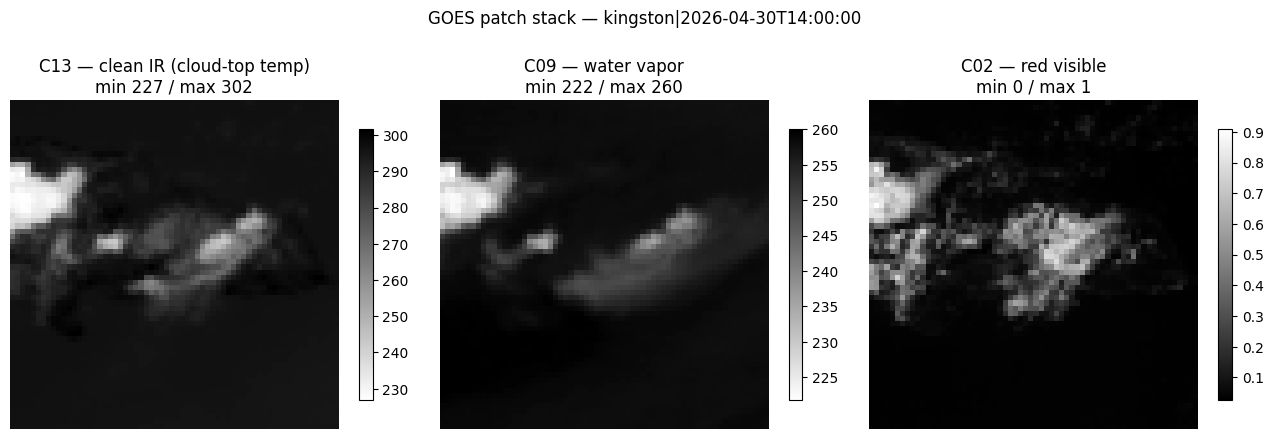

In [7]:
# Pick a daytime key (14:00 local = mid-afternoon, all three bands populated)
day_key = next(k for k in keys if "T14:00:00" in k)
stack = data[day_key]
print(f"Plotting: {day_key}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
titles = ["C13 — clean IR (cloud-top temp)",
          "C09 — water vapor",
          "C02 — red visible"]
cmaps  = ["gray_r", "gray_r", "gray"]   # IR: cold/high = bright; visible: bright = reflective cloud
for ax, ch, title, cmap in zip(axes, stack, titles, cmaps):
    im = ax.imshow(ch, cmap=cmap)
    ax.set_title(f"{title}\nmin {np.nanmin(ch):.0f} / max {np.nanmax(ch):.0f}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle(f"GOES patch stack — {day_key}", y=1.03)
plt.tight_layout()

In [8]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

GOES_DIR = Path.cwd()
while not (GOES_DIR / "requirements.txt").exists():
    GOES_DIR = GOES_DIR.parent
data = np.load(sorted((GOES_DIR/"data"/"raw"/"goes").glob("goes_*.npz"))[-1])

for hr in ["T03:00:00", "T14:00:00"]:
    k = next(key for key in data.keys() if "kingston" in key and hr in key)
    c02 = data[k][2]   # visible channel
    print(f"{hr}: C02 mean={np.nanmean(c02):.3f}  max={np.nanmax(c02):.3f}  "
          f"all-zero={np.all(c02==0)}  any-nan={np.isnan(c02).any()}")

T03:00:00: C02 mean=0.000  max=0.001  all-zero=False  any-nan=False
T14:00:00: C02 mean=0.109  max=0.909  all-zero=False  any-nan=False
